# 1. Install Dependencies

In [1]:
# Core Python and deep learning libraries
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
# Computer vision utilities and image preprocessing tools
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
# Numerical computation and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Evaluation metrics
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
# Import EfficientNet-B0 architecture
from torchvision.models import efficientnet_b0

# Configure GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete. Operating on device: {device}")

Setup complete. Operating on device: cuda


# 2. Dataset Preparation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path to val_idx and test_idx files in Google Drive
val_idx_path = '/content/drive/MyDrive/DeepLearning/val_idx.zip'
test_idx_path = '/content/drive/MyDrive/DeepLearning/test_idx.zip'
baseline_model_path = '/content/drive/MyDrive/DeepLearning/Baseline_model.zip'

Mounted at /content/drive


### 2.1 Data Preprocessing

To prepare the images for training, we'll apply a series of transformations. These transformations ensure that all images are of a consistent size, normalized, and augmented to improve model generalization.

**Transformations:**
-   `Resize(256)`: Resizes the shortest side of the image to 256 pixels while maintaining the aspect ratio.
-   `CenterCrop(224)`: Crops the image to a square of size 224x224 pixels from the center.
-   `ToTensor()`: Converts the image to a PyTorch tensor.
-   `Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`: Normalizes the image pixel values using pre-defined mean and standard deviation values, which are typical for models pre-trained on ImageNet.

In [3]:
# Define transformations for the training, validation, and test sets
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 2.2 Dataset Loading and Splitting

The dataset is loaded using the built in `EuroSAT`class from `torchvision.dataset`. During this phase we apply transfer learning and only use the validation set (from the basline phase). The validation set is split into training, and validation sets with an 80:20 ratio.

-   **Seed for Reproducibility**: A random seed is set to ensure that the dataset split is reproducible.
-   **`train_test_split`**: Used to divide the dataset indices into training and validation sets. The `stratify` parameter ensures that the class distribution is maintained across splits.
-   **`Subset`**: Creates actual dataset subsets based on the generated indices.

In [4]:
# Load EuroSAT Dataset
raw_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transforms.ToTensor())

# Loading dataset with ImageNet-standard transformations
dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# Get class names
class_names = dataset.classes
print(f"Found {len(class_names)} classes: {class_names}")

# Load predefined baseline splits (validation and test indices )
baseline_val_idx = torch.load(val_idx_path, map_location='cpu')
baseline_test_idx = torch.load(test_idx_path, map_location='cpu')

# Re-purpose baseline validation set as the working dataset
# and perform a stratified split (80% training, 20% validation)
# to enable proper early stopping and model selection
val_targets = [dataset.targets[i] for i in baseline_val_idx]

train_idx, val_idx = train_test_split(
    baseline_val_idx,
    test_size=0.20,
    random_state=42,
    stratify=val_targets
)

# Create subsets for train, validation, and test
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, baseline_test_idx)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 347MB/s]


Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train dataset size: 2160
Validation dataset size: 540
Test dataset size: 2700


### 2.3 DataLoader Creation

DataLoaders are essential for efficient batch processing of image data during training and evaluation. They handle shuffling, batching, and loading data in parallel.

-   **`batch_size`**: The number of samples processed in each iteration. A batch size of 32 is a common choice.
-   **`shuffle=True`**: For the training DataLoader, shuffling the data in each epoch helps improve model generalization and prevents the model from learning the order of the training examples.
-   **`num_workers`**: Specifies the number of subprocesses to use for data loading. This can speed up data fetching, especially when transformations are complex. Setting it to 2 is a good starting point.
-   **`pin_memory=True`**: This can speed up data transfer to GPU by pre-pinning memory. It's useful when training on GPU.

These DataLoaders will be used in the training loop to feed data to the model in mini-batches.

In [5]:
# Define batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


# 3. Baseline Model Initialization
---

In [6]:
# Instantiate backbone architecture and adjust output features for EuroSAT (10 classes)
baseline_model = efficientnet_b0(weights=None)
baseline_model.classifier[1] = nn.Linear(baseline_model.classifier[1].in_features, 10)

# Load pretrained baseline model weights
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location=device))
baseline_model = baseline_model.to(device)

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, mode= 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_value = None
        self.early_stop = False
        self.mode = mode

    def __call__(self, value):
        if self.best_value is None:
            self.best_value = value
        elif self._is_worse(value):
            self.counter += 1
            print(f"   [EarlyStopping Update] No improvement counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_value = value
            self.counter = 0

    def _is_worse(self, value):
        if self.mode == 'min':
            return value > self.best_value - self.min_delta
        else:
            return value < self.best_value + self.min_delta

# Training loop for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return (running_loss / len(dataloader)), (100 * correct / total)

# Validation loop for one epoch
def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return (running_loss / len(dataloader)), (100.0 * correct / total)

 # Evaluate model performance and plot confusion matrix
def evaluate_and_plot_matrix(model, dataloader, opt_name):
    model.eval()
    all_preds, all_labels = [], []
    correct_5 = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Calculate Top-5 accuracy
            _, top5 = outputs.topk(5, 1, True, True)
            correct_5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])

    # Calculate performance metrics
    top1 = 100 * (np.array(all_preds) == np.array(all_labels)).mean()
    top5 = 100 * correct_5 / len(dataloader.dataset)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    print("\n" + "="*50)
    print(f"METRICS REPORT: {opt_name}")
    print(f"Top-1 Accuracy: {top1:.2f}% | Top-5 Accuracy: {top5:.2f}%")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f}")
    print("="*50 + "\n")

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {opt_name}')
    plt.xlabel('Predicted Class Labels')
    plt.ylabel('Actual Ground Truth Labels')
    plt.show()

print("Shared metrics and functional pipelines ready.")

Shared metrics and functional pipelines ready.


In [ ]:
# Iterate through the feature extractor to understand the architectural structure of the backbone
for i, layer in enumerate(baseline_model.features):
    print(f"Layer {i}: {type(layer).__name__}")

# Iterate through the classifier head components to understand the final classification layers
for i, layer in enumerate(baseline_model.classifier):
    print(f"Layer {i}: {type(layer).__name__}")

Layer 0: Conv2dNormActivation
Layer 1: Sequential
Layer 2: Sequential
Layer 3: Sequential
Layer 4: Sequential
Layer 5: Sequential
Layer 6: Sequential
Layer 7: Sequential
Layer 8: Conv2dNormActivation
Layer 0: Dropout
Layer 1: Linear


# 4. Model Improvements

### 4.1 Optimizer-Based Optimization Strategies





### Methodology & Experimental Setup

In this phase, we investigate the effect of different optimization algorithms.

To ensure a fair comparison, we evaluate three optimizers under identical conditions:

* **SGD with Momentum**: Uses a velocity term to stabilize gradient updates.

* **RMSprop**: Applies adaptive learning rates based on recent gradient magnitudes.

* **Adam**: Combines momentum and adaptive learning rates for efficient optimization.

To ensure consistency and eliminate experimental bias, all optimizers are evaluated using a unified training pipeline (run_optimizer_experiment). Each run uses the same baseline model, identical data loaders, and the same training and early stopping settings.

In [ ]:
def run_optimizer_experiment(opt_name, optimizer_fn, num_epochs=100, lr=0.1):
    """
    Runs a standardized training pipeline for different optimizers.
    Ensures fair comparison by using identical model setup and training conditions.
    """

    # Model Initialization (from baseline)

    # Create a fresh copy of the baseline model to ensure fair comparison
    model = copy.deepcopy(baseline_model)

    # Freeze all backbone layers
    # Train only the classifier layer
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier[1].parameters():
        param.requires_grad = True

    model = model.to(device)

    # Optimizer & Loss Function

    # Initialize optimizer only on classifier parameters
    optimizer = optimizer_fn(model.classifier[1].parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=5, mode='max')

    # Store training history for visualization and analysis
    history = {
        'train_acc': [],
        'val_acc': [],
        'train_loss': [],
        'val_loss': []
    }

    best_val_acc = 0.0
    best_model_state = None

    # Training Start

    print("\n" + "=" * 60)
    print(f"OPTIMIZER EXPERIMENT: {opt_name}")
    print("=" * 60)

    for epoch in range(num_epochs):

        # Training phase
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

        # Validation phase
        val_loss, val_acc = validate(model, val_loader, criterion)

        # Save metrics per epoch
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Print training progress
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(" ✓ Best!", end="")

        print()

        # Early stopping check
        early_stopping(val_acc)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    # Final Results

    print(f"\nBest Validation Accuracy for {opt_name}: {best_val_acc:.2f}%")

    # Return all results for later evaluation and comparison
    return {
        'model_state': best_model_state,
        'history': history,
        'model': model
    }

* ###  Phase 1: Same Learning Rate as Baseline (LR = 0.1)




#### SGD with Momentum (LR = 0.1)

In [ ]:
# Optimizer Experiment: SGD with Momentum (LR = 0.1)
sgd_results = run_optimizer_experiment(
    "SGD with Momentum",
    optimizer_fn=lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    lr=0.1
)


OPTIMIZER EXPERIMENT: SGD with Momentum
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 0.5728 | Train Acc: 83.80% | Val Loss: 0.4780 | Val Acc: 88.70% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.6001 | Train Acc: 82.36% | Val Loss: 0.5822 | Val Acc: 87.96%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.5387 | Train Acc: 86.99% | Val Loss: 0.5255 | Val Acc: 86.85%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.4698 | Train Acc: 88.06% | Val Loss: 0.6701 | Val Acc: 86.30%
   [EarlyStopping Update] No improvement counter: 3 out of 5
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.4390 | Train Acc: 89.21% | Val Loss: 0.6965 | Val Acc: 85.74%
   [EarlyStopping Update] No improvement counter: 4 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.4233 | Train Acc: 89.12% | Val Loss: 0.6534 | Val Acc: 87.22%
   [EarlyStopping Update] No improvement counter: 5 out of 


METRICS REPORT: SGD with Momentum (LR = 0.1)
Top-1 Accuracy: 88.85% | Top-5 Accuracy: 99.78%
Precision: 0.8923 | Recall: 0.8834



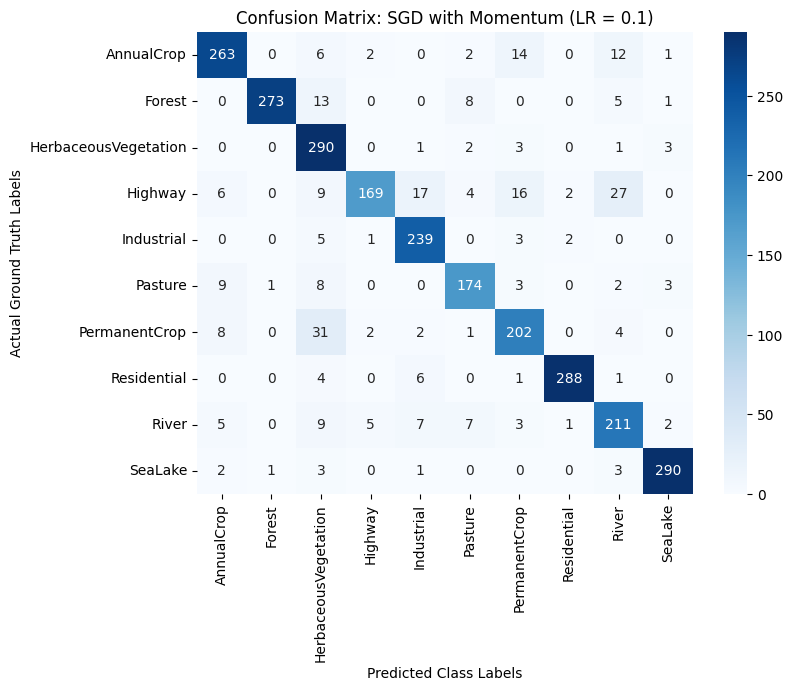

In [ ]:
# Load best model weights (based on validation accuracy)
# Then evaluate final performance on unseen test set
model_sgd = sgd_results['model']
model_sgd.load_state_dict(sgd_results['model_state'])
evaluate_and_plot_matrix(
    model_sgd,
    test_loader,
    "SGD with Momentum (LR = 0.1)"
)

#### RMSprop (LR = 0.1)

In [ ]:
# Optimizer Experiment: RMSprop (LR = 0.1)
rmsprop_results = run_optimizer_experiment(
    "RMSprop",
    optimizer_fn=lambda params, lr: optim.RMSprop(params, lr=lr),
    lr=0.1
)


OPTIMIZER EXPERIMENT: RMSprop
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 19.6787 | Train Acc: 68.10% | Val Loss: 8.9731 | Val Acc: 78.70% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 5.2431 | Train Acc: 82.13% | Val Loss: 5.8041 | Val Acc: 80.74% ✓ Best!
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 4.7363 | Train Acc: 83.52% | Val Loss: 6.8133 | Val Acc: 82.96% ✓ Best!
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 4.3026 | Train Acc: 84.49% | Val Loss: 8.6699 | Val Acc: 81.30%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 3.6047 | Train Acc: 86.02% | Val Loss: 7.4922 | Val Acc: 82.59%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 3.9717 | Train Acc: 86.06% | Val Loss: 7.0860 | Val Acc: 84.44% ✓ Best!
Epoch [ 7/100] | LR: 0.100000 | Train Loss: 3.1894 | Train Acc: 87.87% | Val Loss: 9.0778 | Val Acc: 80.56%
   [EarlyStopping Update] No improvement counter: 1 out of


METRICS REPORT: RMSprop (LR = 0.1)
Top-1 Accuracy: 86.30% | Top-5 Accuracy: 99.37%
Precision: 0.8702 | Recall: 0.8503



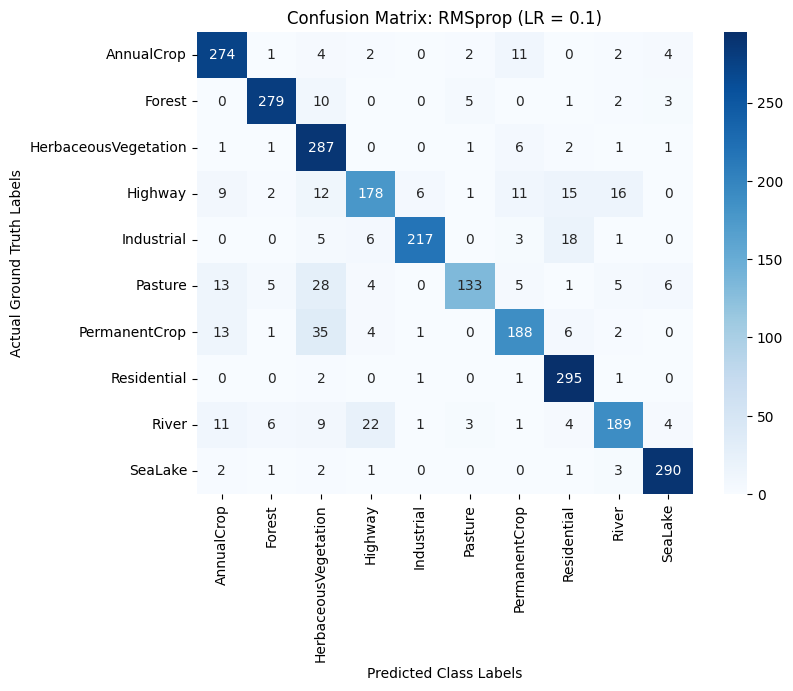

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix
model_rmsprop = rmsprop_results['model']
model_rmsprop.load_state_dict(rmsprop_results['model_state'])

evaluate_and_plot_matrix(
    model_rmsprop,
    test_loader,
    "RMSprop (LR = 0.1)"
)

####Adam (LR = 0.1)

In [ ]:
# Optimizer Experiment: Adam (LR = 0.1)
adam_results = run_optimizer_experiment(
    "Adam",
    optimizer_fn=lambda params, lr: optim.Adam(params, lr=lr),
    lr=0.1
)


OPTIMIZER EXPERIMENT: Adam
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 4.3319 | Train Acc: 69.35% | Val Loss: 3.4236 | Val Acc: 77.96% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 2.8529 | Train Acc: 80.93% | Val Loss: 3.1929 | Val Acc: 83.15% ✓ Best!
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 2.0730 | Train Acc: 85.83% | Val Loss: 3.0123 | Val Acc: 84.44% ✓ Best!
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 2.5691 | Train Acc: 83.89% | Val Loss: 3.3839 | Val Acc: 83.70%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 2.8839 | Train Acc: 84.03% | Val Loss: 4.7149 | Val Acc: 83.15%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 2.3095 | Train Acc: 87.64% | Val Loss: 3.5901 | Val Acc: 86.11% ✓ Best!
Epoch [ 7/100] | LR: 0.100000 | Train Loss: 2.7517 | Train Acc: 86.94% | Val Loss: 4.4433 | Val Acc: 82.41%
   [EarlyStopping Update] No improvement counter: 1 out of 5
E


METRICS REPORT: Adam (LR = 0.1)
Top-1 Accuracy: 86.96% | Top-5 Accuracy: 99.63%
Precision: 0.8741 | Recall: 0.8617



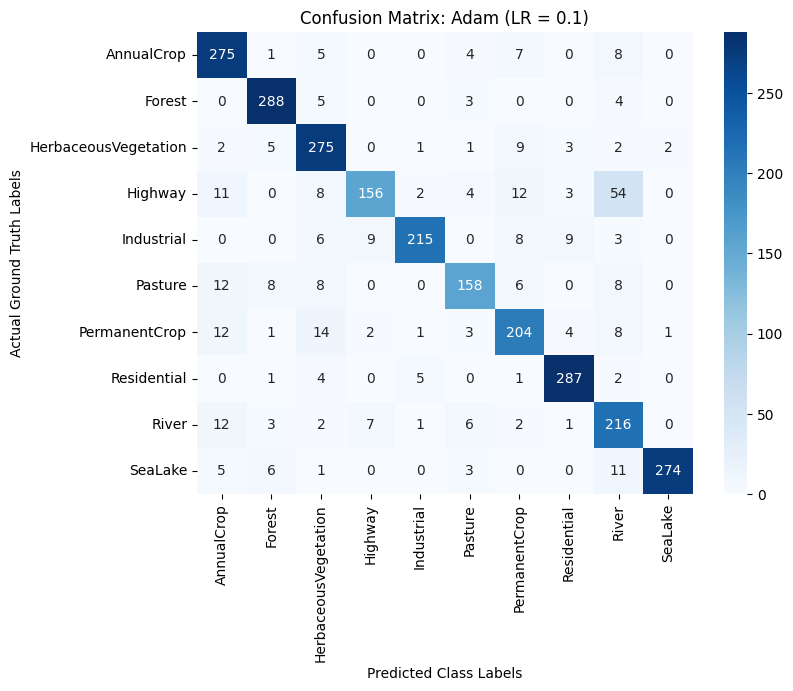

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix
model_adam = adam_results['model']
model_adam.load_state_dict(adam_results['model_state'])

evaluate_and_plot_matrix(
    model_adam,
    test_loader,
    "Adam (LR = 0.1)"
)

###Phase 1: Combined Performance Comparison

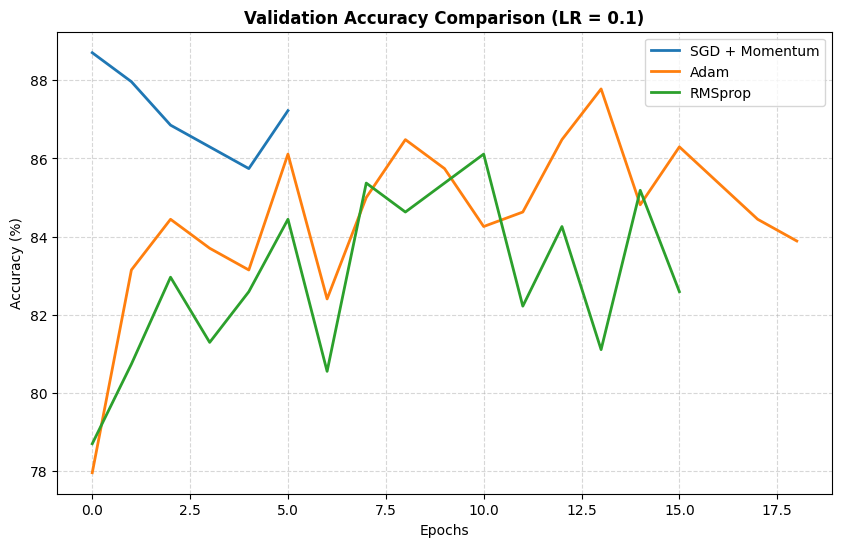

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(sgd_results['history']['val_acc'], label='SGD + Momentum', linewidth=2)
plt.plot(adam_results['history']['val_acc'], label='Adam', linewidth=2)
plt.plot(rmsprop_results['history']['val_acc'], label='RMSprop', linewidth=2)

plt.title("Validation Accuracy Comparison (LR = 0.1)", fontsize=12, fontweight='bold')
plt.xlabel("Epochs", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* ###  Phase 2: Small Learning Rate  (LR = 0.001)


#### SGD with Momentum (LR = 0.001)

In [ ]:
# Optimizer Experiment: SGD with Momentum (LR = 0.001)
sgd_results_p2 = run_optimizer_experiment(
    "SGD with Momentum (Phase 2)",
    optimizer_fn=lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    lr=0.001
)


OPTIMIZER EXPERIMENT: SGD with Momentum (Phase 2)
Epoch [ 1/100] | LR: 0.001000 | Train Loss: 0.3420 | Train Acc: 88.24% | Val Loss: 0.2788 | Val Acc: 91.30% ✓ Best!
Epoch [ 2/100] | LR: 0.001000 | Train Loss: 0.3540 | Train Acc: 87.64% | Val Loss: 0.2895 | Val Acc: 91.67% ✓ Best!
Epoch [ 3/100] | LR: 0.001000 | Train Loss: 0.3444 | Train Acc: 87.96% | Val Loss: 0.2826 | Val Acc: 90.93%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 4/100] | LR: 0.001000 | Train Loss: 0.3568 | Train Acc: 87.41% | Val Loss: 0.2809 | Val Acc: 91.30%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 5/100] | LR: 0.001000 | Train Loss: 0.3188 | Train Acc: 89.44% | Val Loss: 0.2936 | Val Acc: 90.56%
   [EarlyStopping Update] No improvement counter: 3 out of 5
Epoch [ 6/100] | LR: 0.001000 | Train Loss: 0.3210 | Train Acc: 88.84% | Val Loss: 0.2760 | Val Acc: 90.56%
   [EarlyStopping Update] No improvement counter: 4 out of 5
Epoch [ 7/100] | LR: 0.001000 | Train Los


METRICS REPORT: SGD with Momentum (LR = 0.001)
Top-1 Accuracy: 92.48% | Top-5 Accuracy: 99.78%
Precision: 0.9246 | Recall: 0.9202



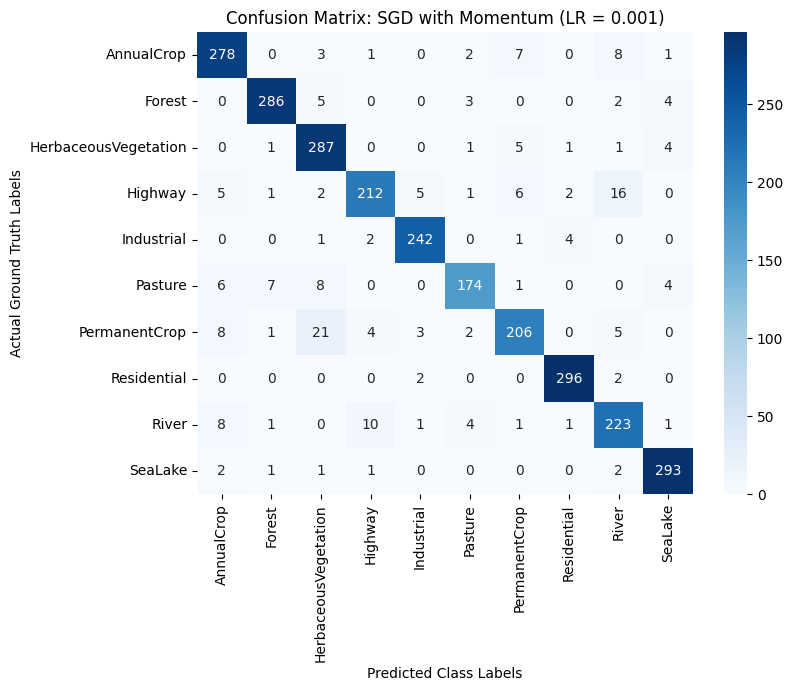

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix (Phase 2)
model_sgd_p2 = sgd_results_p2['model']
model_sgd_p2.load_state_dict(sgd_results_p2['model_state'])

evaluate_and_plot_matrix(
    model_sgd_p2,
    test_loader,
    "SGD with Momentum (LR = 0.001)"
)

#### RMSprop (LR = 0.001)

In [ ]:
# Optimizer Experiment: RMSprop (LR = 0.001)
rmsprop_results_p2 = run_optimizer_experiment(
    "RMSprop (Phase 2)",
    optimizer_fn=lambda params, lr: optim.RMSprop(params, lr=lr),
    lr=0.001
)


OPTIMIZER EXPERIMENT: RMSprop (Phase 2)
Epoch [ 1/100] | LR: 0.001000 | Train Loss: 0.3827 | Train Acc: 87.64% | Val Loss: 0.2865 | Val Acc: 90.37% ✓ Best!
Epoch [ 2/100] | LR: 0.001000 | Train Loss: 0.3375 | Train Acc: 88.98% | Val Loss: 0.2883 | Val Acc: 90.37%
Epoch [ 3/100] | LR: 0.001000 | Train Loss: 0.3060 | Train Acc: 89.12% | Val Loss: 0.2824 | Val Acc: 91.30% ✓ Best!
Epoch [ 4/100] | LR: 0.001000 | Train Loss: 0.3042 | Train Acc: 89.35% | Val Loss: 0.2864 | Val Acc: 90.93%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.001000 | Train Loss: 0.2423 | Train Acc: 91.53% | Val Loss: 0.2886 | Val Acc: 90.37%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 6/100] | LR: 0.001000 | Train Loss: 0.2665 | Train Acc: 90.74% | Val Loss: 0.2849 | Val Acc: 91.67% ✓ Best!
Epoch [ 7/100] | LR: 0.001000 | Train Loss: 0.2275 | Train Acc: 91.39% | Val Loss: 0.2970 | Val Acc: 90.19%
   [EarlyStopping Update] No improvement counter: 1 out o


METRICS REPORT: RMSprop (LR = 0.001)
Top-1 Accuracy: 92.52% | Top-5 Accuracy: 99.81%
Precision: 0.9237 | Recall: 0.9212



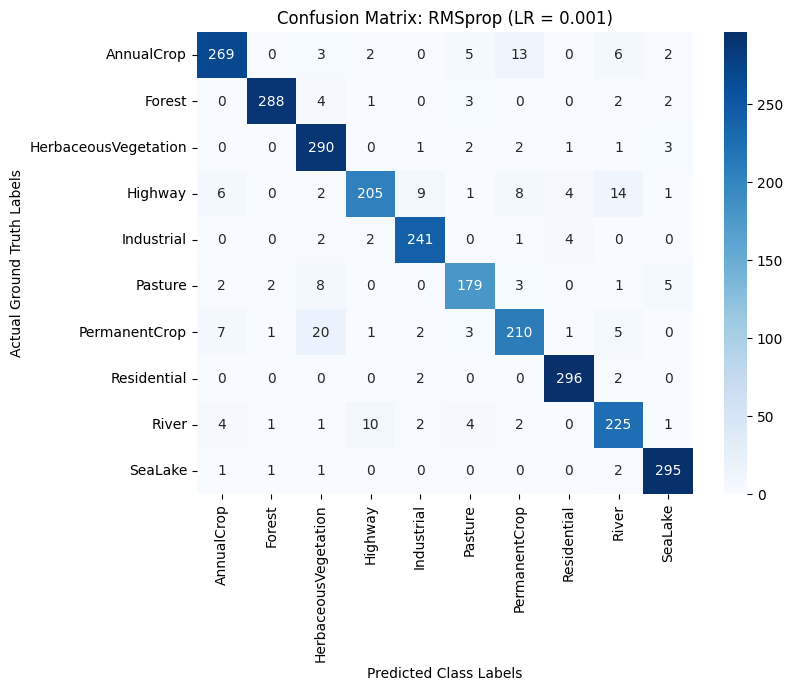

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix (Phase 2)
model_rmsprop_p2 = rmsprop_results_p2['model']
model_rmsprop_p2.load_state_dict(rmsprop_results_p2['model_state'])

evaluate_and_plot_matrix(
    model_rmsprop_p2,
    test_loader,
    "RMSprop (LR = 0.001)"
)

Adam (LR = 0.001)

In [ ]:
# Optimizer Experiment: Adam (LR = 0.001)
adam_results_p2 = run_optimizer_experiment(
    "Adam (Phase 2)",
    optimizer_fn=lambda params, lr: optim.Adam(params, lr=lr),
    lr=0.001
)


OPTIMIZER EXPERIMENT: Adam (Phase 2)
Epoch [ 1/100] | LR: 0.001000 | Train Loss: 0.3672 | Train Acc: 87.82% | Val Loss: 0.2794 | Val Acc: 90.00% ✓ Best!
Epoch [ 2/100] | LR: 0.001000 | Train Loss: 0.3356 | Train Acc: 88.47% | Val Loss: 0.2877 | Val Acc: 90.19% ✓ Best!
Epoch [ 3/100] | LR: 0.001000 | Train Loss: 0.3217 | Train Acc: 89.03% | Val Loss: 0.2856 | Val Acc: 90.74% ✓ Best!
Epoch [ 4/100] | LR: 0.001000 | Train Loss: 0.3021 | Train Acc: 90.32% | Val Loss: 0.2824 | Val Acc: 90.37%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.001000 | Train Loss: 0.2746 | Train Acc: 89.91% | Val Loss: 0.2908 | Val Acc: 89.81%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 6/100] | LR: 0.001000 | Train Loss: 0.2804 | Train Acc: 90.65% | Val Loss: 0.2868 | Val Acc: 90.74%
Epoch [ 7/100] | LR: 0.001000 | Train Loss: 0.2783 | Train Acc: 90.19% | Val Loss: 0.2878 | Val Acc: 91.30% ✓ Best!
Epoch [ 8/100] | LR: 0.001000 | Train Loss: 0.2706 |


METRICS REPORT: Adam (LR = 0.001)
Top-1 Accuracy: 92.41% | Top-5 Accuracy: 99.96%
Precision: 0.9236 | Recall: 0.9198



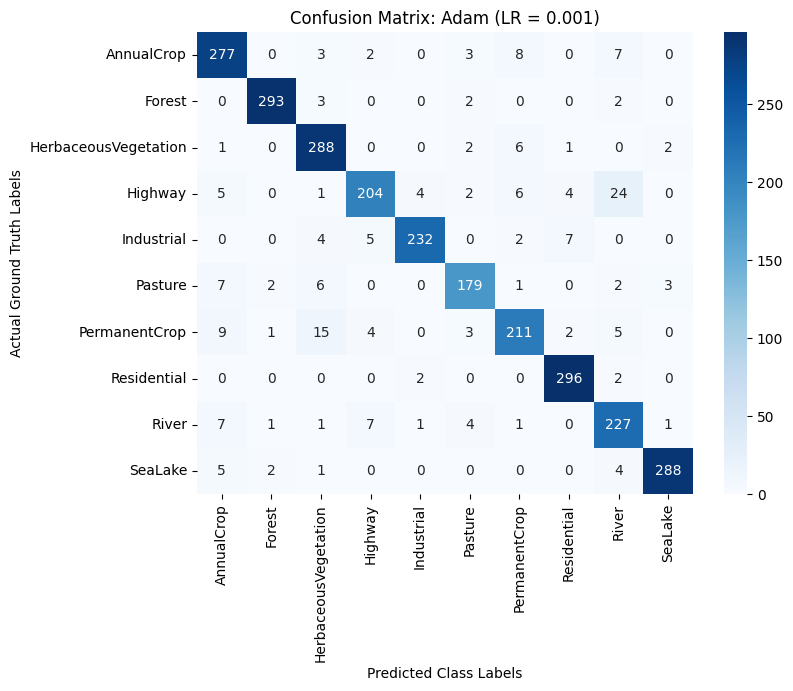

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix (Phase 2)
model_adam_p2 = adam_results_p2['model']
model_adam_p2.load_state_dict(adam_results_p2['model_state'])

evaluate_and_plot_matrix(
    model_adam_p2,
    test_loader,
    "Adam (LR = 0.001)"
)

###Phase 2: Combined Performance Comparison

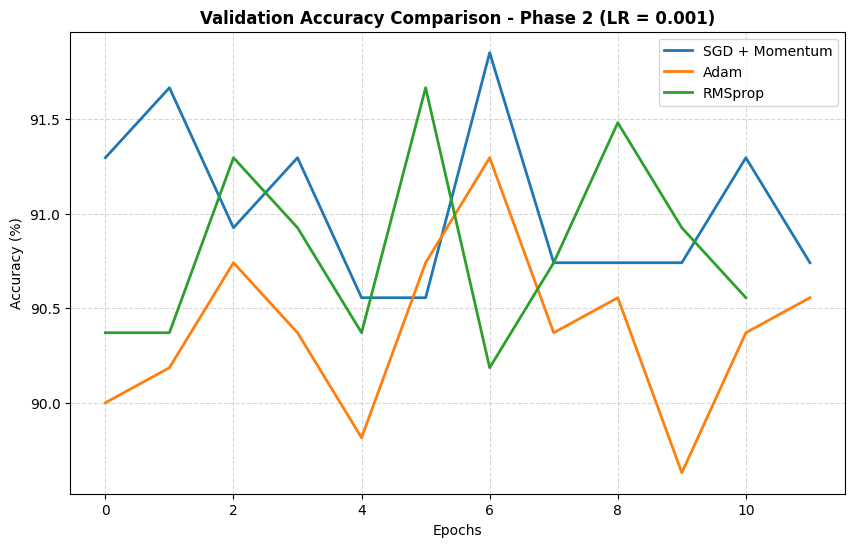

In [ ]:
plt.figure(figsize=(10, 6))

# Plot validation accuracy histories from each experiment in Phase 2
plt.plot(sgd_results_p2['history']['val_acc'], label='SGD + Momentum', linewidth=2)
plt.plot(adam_results_p2['history']['val_acc'], label='Adam', linewidth=2)
plt.plot(rmsprop_results_p2['history']['val_acc'], label='RMSprop', linewidth=2)

plt.title("Validation Accuracy Comparison - Phase 2 (LR = 0.001)", fontsize=12, fontweight='bold')
plt.xlabel("Epochs", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4.2 Regularization Improvements:

---



#### Methodology
In this phase, we investigate the effect of different regularization techniques to mitigate overfitting and enhance the generalization capability of the fine-tuned model on the EuroSAT dataset.

We evaluated two primary regularization methods with learning rate ($0.1$):
* **Dropout Regularization:** Randomly deactivates a specified percentage of neurons during training to prevent feature co-adaptation and encourage the network to learn more robust, distributed representations.

* **Weight Decay (L2 Regularization):** Adds a penalty term proportional to the square of the weights to the loss function, forcing the weights to remain small and smoothing the model's decision boundaries.


To maintain consistency and eliminate experimental bias, all regularization experiments utilizes the identical architecture baseline (`EfficientNet-B0`), consistent data loaders, and identical early stopping settings (Patience = 5).


#### Experiment 1: Dropout Regularization
This experiment explores the impact of structural noise on feature extraction by testing moderate versus aggressive neural dropping rates across different optimization speeds.

##### Hyperparameter Tuning:
* dropout_rates = [0.2, 0.4]
* learning_rate = [0.1]

In [ ]:
# Hyperparameter Tuning: Regularization
learning_rates = [0.1]

# Dictionary to store all experiments results for later analysis/plotting
dropout_experiment_results = {}

# Global tracking variables to store the BEST model across ALL experiments
global_best_val_acc = 0.0
global_best_lr = 0.0
global_best_drop = None

# Dropout values to evaluate regularization strength
dropout_values = [0.2, 0.4]

# Loop over dropout rates (regularization strength)
for drop_rate in dropout_values:

  # Loop over learning rates (only one fixed value here)
  for lr in learning_rates:

    # Create a fresh copy of the baseline model for each experiment
    model_drop = copy.deepcopy(baseline_model)
    model_drop = model_drop.to(device)

    # Replace classifier dropout layer with current dropout rate
    model_drop.classifier[0] = nn.Dropout(p=drop_rate, inplace=True)

    # Freeze all model parameters (feature extractor)
    for param in model_drop.parameters():
        param.requires_grad = False

    # Unfreeze only classifier parameters (trainable part)
    for param in model_drop.classifier.parameters():
        param.requires_grad = True

    # Define optimizer (SGD with fixed learning rate = 0.1)
    optimizer_drop = optim.SGD(
        model_drop.classifier[1].parameters(),
        lr=0.1,
        momentum=0.0
    )

    # Loss function for classification task
    criterion_drop = nn.CrossEntropyLoss()

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(patience=5, mode='max')

    # Store training history for analysis/plots
    trial_history = {
        'train_acc': [],
        'val_acc': [],
        'train_loss': [],
        'val_loss': []
    }

    num_epochs = 100

    # Best validation accuracy for THIS specific experiment
    best_val_acc = 0.0
    best_model_state_drop = None

    print("\n" + "=" * 60)
    print(f"IMPROVEMENT: Regularization using Dropout Rate: {drop_rate} and LR: {lr}")
    print("=" * 60)

    # Training loop
    for epoch in range(num_epochs):

        # Train phase
        train_loss, train_acc = train_one_epoch(
            model_drop, train_loader, criterion_drop, optimizer_drop
        )

        # Validation phase
        val_loss, val_acc = validate(
            model_drop, val_loader, criterion_drop
        )

        # Save metrics for analysis
        trial_history['train_acc'].append(train_acc)
        trial_history['val_acc'].append(val_acc)
        trial_history['train_loss'].append(train_loss)
        trial_history['val_loss'].append(val_loss)

        # Print training progress
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
              f"LR: {optimizer_drop.param_groups[0]['lr']:.6f} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

        # Save BEST model for this experiment
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state_drop = copy.deepcopy(model_drop.state_dict())

            # Update GLOBAL best model across all experiments
            if val_acc > global_best_val_acc:
                global_best_val_acc = val_acc
                global_best_lr = lr
                global_best_drop = drop_rate

            print(" ✓ Best!", end="")

        print()

        # Early stopping check
        early_stopping(val_acc)
        if early_stopping.early_stop:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    # Save results for this (dropout, lr) combination
    dropout_experiment_results[(drop_rate, lr)] = {
        'model_state': best_model_state_drop,
        'history': trial_history
    }

    print(f"\nBest Validation Accuracy for drop rate {drop_rate} and LR {lr}: {best_val_acc:.2f}%")

# FINAL SELECTION: choose the best model across ALL experiments
best_val_acc = global_best_val_acc
best_lr = global_best_lr

print(f"\nOptimization Finished. Best Learning Rate: {best_lr} with Accuracy: {best_val_acc:.2f}%")


IMPROVEMENT: Regularization using Dropout Rate: 0.2 and LR: 0.1
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 0.3616 | Train Acc: 87.45% | Val Loss: 0.2850 | Val Acc: 90.93% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.3284 | Train Acc: 88.98% | Val Loss: 0.2832 | Val Acc: 90.56%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.3314 | Train Acc: 89.26% | Val Loss: 0.2746 | Val Acc: 90.74%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.3071 | Train Acc: 89.44% | Val Loss: 0.2947 | Val Acc: 90.93%
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.2684 | Train Acc: 90.14% | Val Loss: 0.2804 | Val Acc: 89.81%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.2632 | Train Acc: 91.30% | Val Loss: 0.2873 | Val Acc: 90.74%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 7/100] | LR: 0.100000 | Tra


--- Confusion Matrix for drop rate = 0.2 ---

METRICS REPORT: Dropout 0.2 
Top-1 Accuracy: 92.26% | Top-5 Accuracy: 99.89%
Precision: 0.9233 | Recall: 0.9182



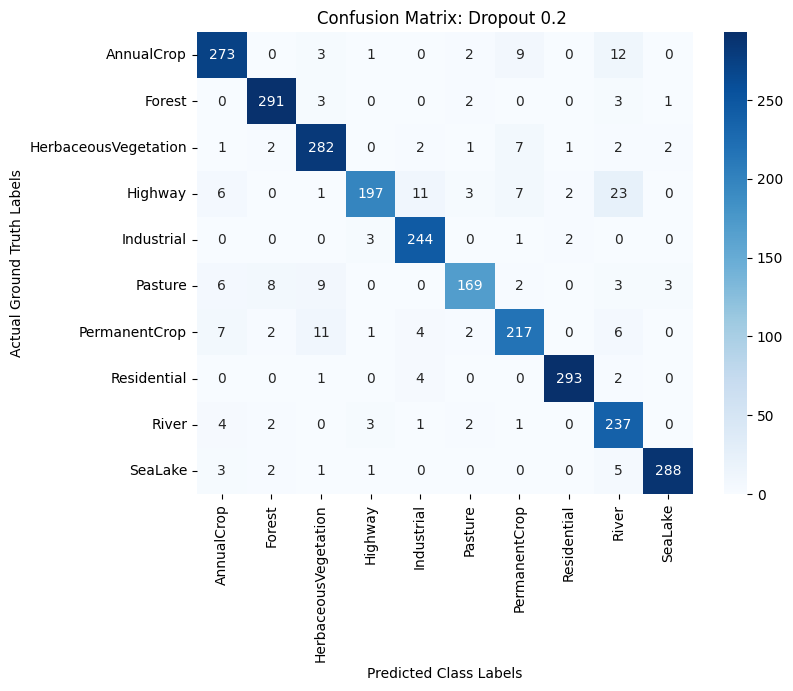


--- Confusion Matrix for drop rate = 0.4 ---

METRICS REPORT: Dropout 0.4 
Top-1 Accuracy: 91.81% | Top-5 Accuracy: 99.85%
Precision: 0.9190 | Recall: 0.9124



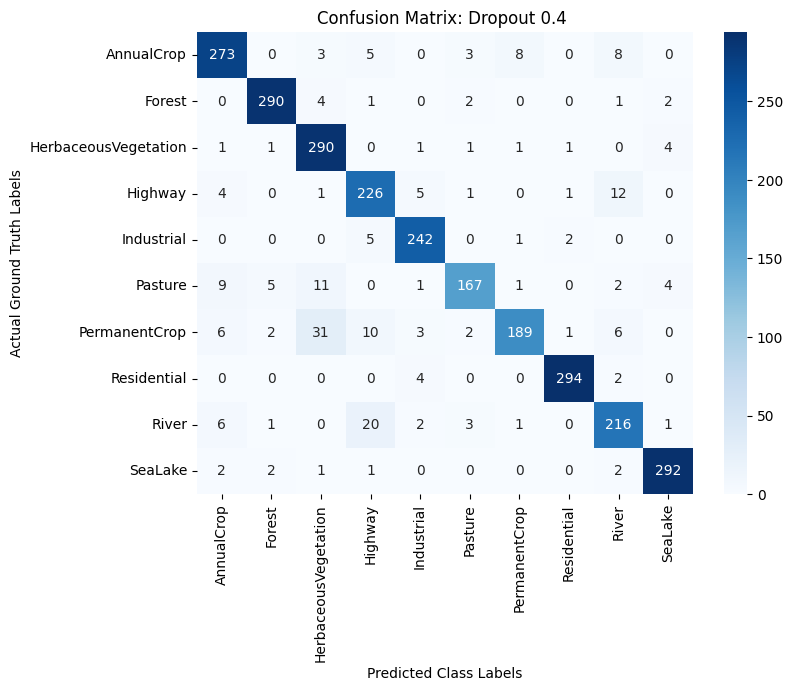

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix
for (drop_rate, lr), data in dropout_experiment_results.items():
    print(f"\n--- Confusion Matrix for drop rate = {drop_rate} ---")

    # Loading Best Model Weights
    model_drop.load_state_dict(data['model_state'])

    # Evaluating
    evaluate_and_plot_matrix(model_drop, test_loader, f"Dropout {drop_rate} ")

#### Experiment 2: Weight Decay Regularization
This experiment evaluates the interaction between weight penalties and optimization step sizes to fine-tune the model’s parameters smoothly.

##### Hyperparameter Tuning:
* learning_rate = [0.1]
* weight_decay = 1e-4

In [ ]:
# Hyperparameter Tuning: Learning Rate Exploration
learning_rates = [0.1]
best_lr = 0.0
experiment_results = {} # To store results for comparison plotting

# GLOBAL tracking for best model across all experiments
global_best_val_acc = 0.0
global_best_lr = 0.0

# Loop over each Learning rate value to run the experiment independently
for lr in learning_rates:
  # Setup: Create a copy of the baseline model
  model_wd = copy.deepcopy(baseline_model)
  model_wd = model_wd.to(device)

  # Freeze backbone, train classifier head parameters only
  # Freeze all parameters first
  for param in model_wd.parameters():
      param.requires_grad = False

  # Unfreeze the classifier
  for param in model_wd.classifier.parameters():
      param.requires_grad = True

  # Training Configuration
  # Initialize SGD Optimizer and inject the specific Weight Decay value
  # We use 1e-4 (0.0001) as a standard regularization value to penalize large weights
  optimizer_wd = optim.SGD(
      model_wd.classifier[1].parameters(),
      lr=0.1,
      momentum=0.0,
      weight_decay=1e-4
  )

  early_stopping = EarlyStopping(patience=5, mode='max')
  criterion_wd = nn.CrossEntropyLoss()
  trial_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

  # Training Loop
  num_epochs = 100
  best_val_acc = 0.0
  best_model_state_wd = None

  print("\n" + "=" * 60)
  print(f"IMPROVEMENT: Regularization using Weight Decay Regularization and LR: {lr}")
  print("=" * 60)

  # Execution phase (maximum 100 epochs with early stopping)
  for epoch in range(num_epochs):

    # Training
    train_loss, train_acc = train_one_epoch(
        model_wd, train_loader, criterion_wd, optimizer_wd
    )

    # Validation
    val_loss, val_acc = validate(
        model_wd, val_loader, criterion_wd
        )

    # Save history for plotting
    trial_history['train_acc'].append(train_acc)
    trial_history['val_acc'].append(val_acc)
    trial_history['train_loss'].append(train_loss)
    trial_history['val_loss'].append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"LR: {optimizer_wd.param_groups[0]['lr']:.6f} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_wd = copy.deepcopy(model_wd.state_dict())
        best_lr = lr

        # GLOBAL BEST UPDATE
        if val_acc > global_best_val_acc:
            global_best_val_acc = val_acc
            global_best_lr = lr

        print(" ✓ Best!", end="")

    print()

    # Early Stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

  # Final evaluation on unseen test dataset and matrix visualization for each rate
  experiment_results[lr] = {'model_state': best_model_state_wd, 'history': trial_history}
  print(f"\nBest Validation Accuracy for LR {lr}: {best_val_acc:.2f}%")

# FINAL BEST SELECTION
best_val_acc = global_best_val_acc
best_lr = global_best_lr

print(f"\nOptimization Finished. Best Learning Rate: {best_lr} with Accuracy: {best_val_acc:.2f}%")


IMPROVEMENT: Regularization using Weight Decay Regularization and LR: 0.1
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 0.3482 | Train Acc: 88.10% | Val Loss: 0.2936 | Val Acc: 90.37% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.3233 | Train Acc: 88.98% | Val Loss: 0.2846 | Val Acc: 90.37%
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.3375 | Train Acc: 88.66% | Val Loss: 0.2859 | Val Acc: 90.93% ✓ Best!
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.3148 | Train Acc: 89.63% | Val Loss: 0.2896 | Val Acc: 90.56%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.2958 | Train Acc: 90.23% | Val Loss: 0.2860 | Val Acc: 91.11% ✓ Best!
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.2869 | Train Acc: 90.60% | Val Loss: 0.2976 | Val Acc: 91.30% ✓ Best!
Epoch [ 7/100] | LR: 0.100000 | Train Loss: 0.2873 | Train Acc: 90.88% | Val Loss: 0.2874 | Val Acc: 90.37%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 8/100] 


--- Confusion Matrix for weight_decay = 1e-4 ---

METRICS REPORT: weight_decay=1e-4
Top-1 Accuracy: 92.30% | Top-5 Accuracy: 99.93%
Precision: 0.9207 | Recall: 0.9200



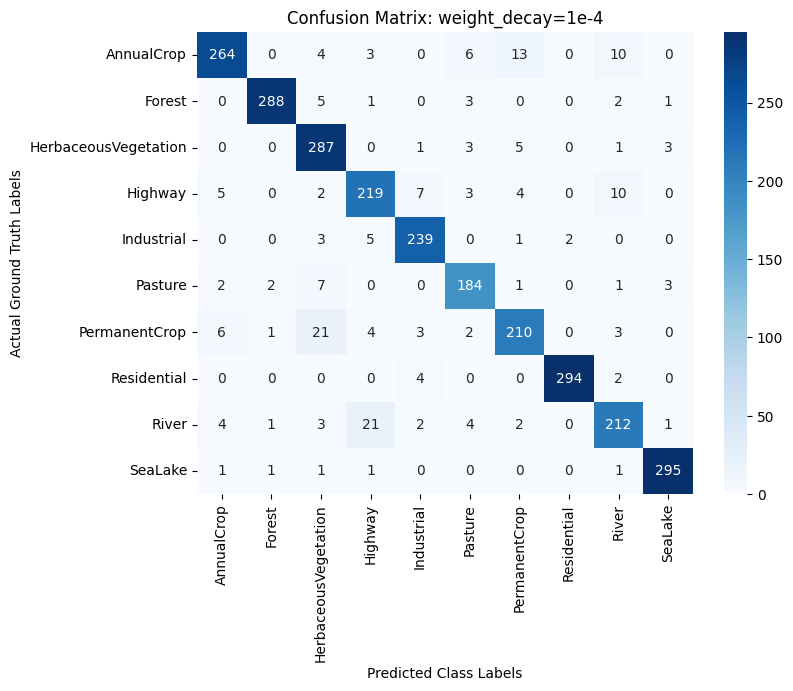

In [ ]:
# Final Evaluation: Test Set + Confusion Matrix
for lr, data in experiment_results.items():
    print(f"\n--- Confusion Matrix for weight_decay = 1e-4 ---")

    # Loading Best Model Weights
    model_wd.load_state_dict(data['model_state'])

    # Evaluating
    evaluate_and_plot_matrix(model_wd, test_loader, f"weight_decay=1e-4")

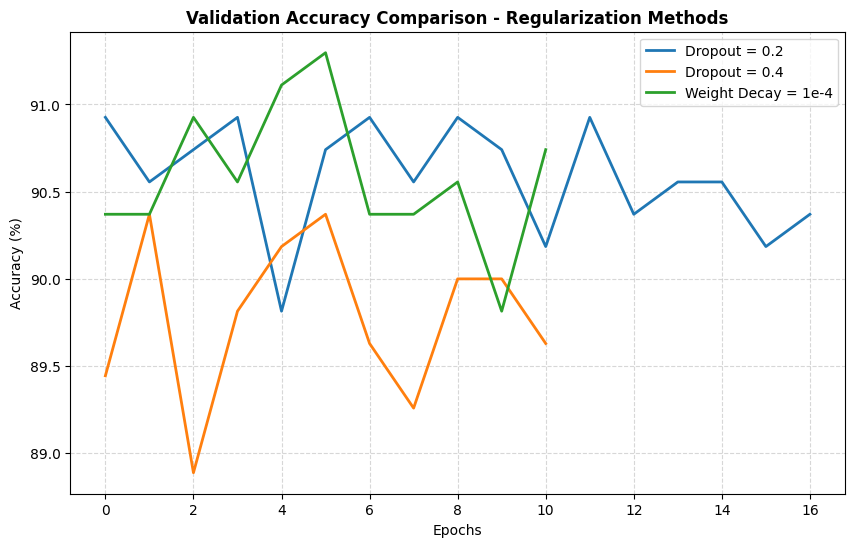

In [ ]:
plt.figure(figsize=(10, 6))

# Dropout = 0.2
for (dr, lr), result in dropout_experiment_results.items():
    if dr == 0.2 and lr == 0.1:
        plt.plot(result['history']['val_acc'], label='Dropout = 0.2', linewidth=2)

# Dropout = 0.4
for (dr, lr), result in dropout_experiment_results.items():
    if dr == 0.4 and lr == 0.1:
        plt.plot(result['history']['val_acc'], label='Dropout = 0.4', linewidth=2)

# Weight Decay (weight_decay = 1e-4)
for lr, result in experiment_results.items():
    if lr == 0.1:
        plt.plot(result['history']['val_acc'], label='Weight Decay = 1e-4', linewidth=2)

plt.title("Validation Accuracy Comparison - Regularization Methods", fontsize=12, fontweight='bold')
plt.xlabel("Epochs", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 4.3 Training (Fine-Tuning) Strategies:

---

#### Methodology:
---

In these experiments, we employed a transfer learning approach to investigate the effect of using unfreezing algorithms.
In all experiments, we kept the majority of the model's backbone frozen and focused on fine-tuning the classifier and the last two blocks of the model to better recognize satellite imagery.

**Our improvements were conducted in three steps:**
* **Unfreezing more layers**: We unfreeze the classifier and the last two blocks of the model.  

* **Discriminative Learning Rates:** To preserve the pre-trained features while allowing the model to learn the new task, we applied different learning rates to different layers. We assigned a very low learning rate to the backbone (to avoid "forgetting") and a higher learning rate to the classifier (to facilitate faster adaptation).
* **Learning Rate Scheduling:** Finally, we implemented a **ReduceLROnPlateau scheduler**. This automatically reduced the learning rate whenever the validation accuracy stopped improving. This technique help the model "fine-tune" its weights more carefully in the final stages of training, leading to better convergence.


To maintain consistency and eliminate experimental bias, all experiments utilizes the identical architecture baseline wieghts, consistent data loaders, and identical early stopping settings (Patience = 5).


In [8]:
# store results for comparison plotting
ft_experiment_results = pd.DataFrame(columns=['model_state', 'history','experiment_name'])

#### Experiment 1: Unfreezing more layers
---

In [10]:
# Setup: Create a copy of the baseline model
model_ft = copy.deepcopy(baseline_model)
model_ft = model_ft.to(device)

# UNFREEZING STRATEGY
# Freeze all parameters first
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze the classifier
for param in model_ft.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the backbone (features)
for i, child in enumerate(model_ft.features):
    if i >= 7: # Unfreezing layers 7, 8
        for param in child.parameters():
            param.requires_grad = True

# Training Configuration
# Initialize optimizer (SGD with Momentum) identical to baseline configuration
optimizer_ft = optim.SGD(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.1,
    momentum=0.0)
criterion_ft = nn.CrossEntropyLoss()
early_stopping = EarlyStopping(patience=5, mode='max')
trial_history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
    }

# Training Loop
num_epochs = 100
best_val_acc = 0.0
best_model_state_ft = None

print("\n" + "=" * 60)
print(f"IMPROVEMENT: Fine-Tuning with Unfreezing more layers")
print("=" * 60)

for epoch in range(num_epochs):
    # Training
    train_loss, train_acc = train_one_epoch(
        model_ft, train_loader, criterion_ft, optimizer_ft
    )

    # Validation
    val_loss, val_acc = validate(
        model_ft, val_loader, criterion_ft
        )

    # Save history for plotting
    trial_history['train_acc'].append(train_acc)
    trial_history['val_acc'].append(val_acc)
    trial_history['train_loss'].append(train_loss)
    trial_history['val_loss'].append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"LR: {optimizer_ft.param_groups[0]['lr']:.6f} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_ft = copy.deepcopy(model_ft.state_dict())
        print(" ✓ Best!", end="")

    print()

    # Early Stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Store results for comparison
new_result = pd.DataFrame([{'model_state': best_model_state_ft, 'history': trial_history, 'experiment_name': 'Unfreezing more layers'}])
ft_experiment_results = pd.concat([ft_experiment_results, new_result], ignore_index=True)
print(f"\nOptimization Finished. Best Accuracy: {best_val_acc:.2f}%")


IMPROVEMENT: Fine-Tuning with Unfreezing more layers
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 0.4086 | Train Acc: 87.69% | Val Loss: 0.3021 | Val Acc: 91.30% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.1927 | Train Acc: 93.66% | Val Loss: 0.3501 | Val Acc: 90.93%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.1264 | Train Acc: 95.83% | Val Loss: 0.2795 | Val Acc: 91.11%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.1019 | Train Acc: 96.30% | Val Loss: 0.2737 | Val Acc: 92.22% ✓ Best!
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.0994 | Train Acc: 96.53% | Val Loss: 0.2557 | Val Acc: 91.48%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.0875 | Train Acc: 97.27% | Val Loss: 0.2767 | Val Acc: 92.04%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 7/100] | LR: 0.100000 | Train 


METRICS REPORT: Unfreezing more layers
Top-1 Accuracy: 94.00% | Top-5 Accuracy: 99.93%
Precision: 0.9409 | Recall: 0.9367



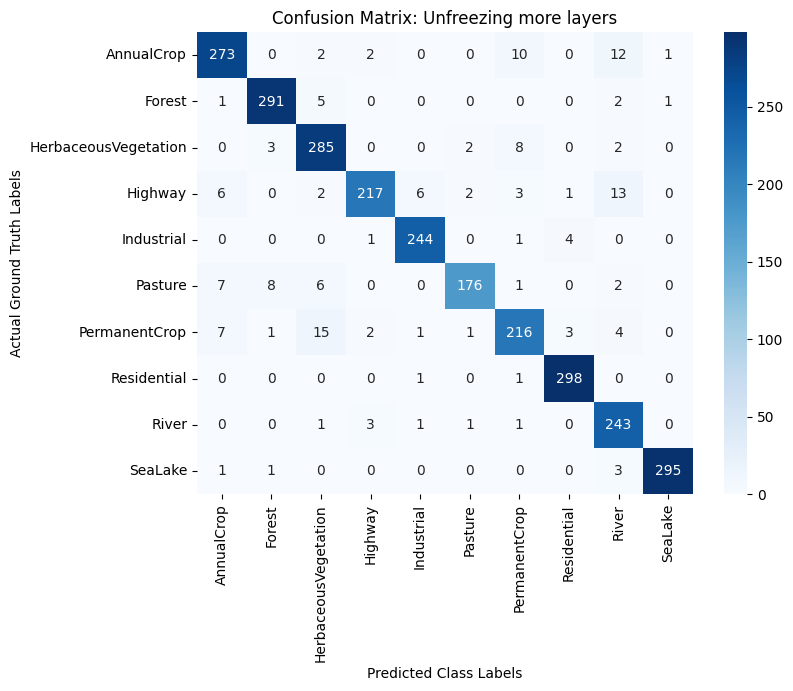

In [11]:
# Final Evaluation: Test Set + Confusion Matrix
# Loading Best Model Weights
if best_model_state_ft is not None:
    model_ft.load_state_dict(best_model_state_ft)

# Evaluating
evaluate_and_plot_matrix(
    model_ft,
    test_loader,
    "Unfreezing more layers"
    )

#### Experiment 2: Discriminative Learning Rates

In [12]:
# Setup: Create a copy of the baseline model
model_ft_2 = copy.deepcopy(baseline_model)
model_ft_2 = model_ft_2.to(device)

# UNFREEZING STRATEGY
# Freeze all parameters first
for param in model_ft_2.parameters():
    param.requires_grad = False

# Unfreeze the classifier
for param in model_ft_2.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the backbone (features)
params_backbone = []
for i, child in enumerate(model_ft_2.features):
    if i >= 7:
        for param in child.parameters():
            param.requires_grad = True
            params_backbone.append(param)

# Training Configuration
# DISCRIMINATIVE LEARNING RATE CONFIGURATION
optimizer_ft = optim.SGD([
    {'params': params_backbone, 'lr': 1e-4},
    {'params': model_ft_2.classifier.parameters(), 'lr': 1e-3}
], momentum=0.9)

criterion_ft = nn.CrossEntropyLoss()
trial_history = {'train_acc': [],
                 'val_acc': [],
                 'train_loss': [],
                 'val_loss': []}

early_stopping = EarlyStopping(patience=5, mode='max')

# Training Loop
num_epochs = 100
best_val_acc = 0.0
best_model_state_ft = None

print("\n" + "=" * 60)
print("IMPROVEMENT: Fine-Tuning with Discriminative Learning Rate")
print("=" * 60)

for epoch in range(100):
    # Training
      train_loss, train_acc = train_one_epoch(
          model_ft_2, train_loader, criterion_ft, optimizer_ft
      )

      # Validation
      val_loss, val_acc = validate(model_ft_2, val_loader, criterion_ft)

      # Save history for plotting
      trial_history['train_acc'].append(train_acc)
      trial_history['val_acc'].append(val_acc)
      trial_history['train_loss'].append(train_loss)
      trial_history['val_loss'].append(val_loss)

      print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
            f"LR: {optimizer_ft.param_groups[0]['lr']:.6f} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

      if val_acc > best_val_acc:
          best_val_acc = val_acc
          best_model_state_ft = copy.deepcopy(model_ft_2.state_dict())
          print(" ✓ Best!", end="")

      print()

      # Early Stopping
      early_stopping(val_acc)
      if early_stopping.early_stop:
          print(f"\nEarly stopping at epoch {epoch+1}")
          break

# Store results for comparison
new_result = pd.DataFrame([{'model_state': best_model_state_ft, 'history': trial_history, 'experiment_name': 'Discriminative Learning Rate'}])
ft_experiment_results = pd.concat([ft_experiment_results, new_result], ignore_index=True)
print(f"\nOptimization Finished. Best Validation Accuracy: {best_val_acc:.2f}%")


IMPROVEMENT: Fine-Tuning with Discriminative Learning Rate
Epoch [ 1/100] | LR: 0.000100 | Train Loss: 0.3692 | Train Acc: 87.87% | Val Loss: 0.2820 | Val Acc: 90.93% ✓ Best!
Epoch [ 2/100] | LR: 0.000100 | Train Loss: 0.3396 | Train Acc: 88.61% | Val Loss: 0.2828 | Val Acc: 90.74%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 3/100] | LR: 0.000100 | Train Loss: 0.3325 | Train Acc: 88.70% | Val Loss: 0.2783 | Val Acc: 90.56%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 4/100] | LR: 0.000100 | Train Loss: 0.3085 | Train Acc: 89.81% | Val Loss: 0.2694 | Val Acc: 90.93%
Epoch [ 5/100] | LR: 0.000100 | Train Loss: 0.2869 | Train Acc: 89.91% | Val Loss: 0.2671 | Val Acc: 91.11% ✓ Best!
Epoch [ 6/100] | LR: 0.000100 | Train Loss: 0.2706 | Train Acc: 90.65% | Val Loss: 0.2604 | Val Acc: 91.30% ✓ Best!
Epoch [ 7/100] | LR: 0.000100 | Train Loss: 0.3060 | Train Acc: 89.58% | Val Loss: 0.2750 | Val Acc: 91.30%
Epoch [ 8/100] | LR: 0.000100 | Train 


METRICS REPORT: Discriminative Learning Rates
Top-1 Accuracy: 92.96% | Top-5 Accuracy: 99.96%
Precision: 0.9288 | Recall: 0.9258



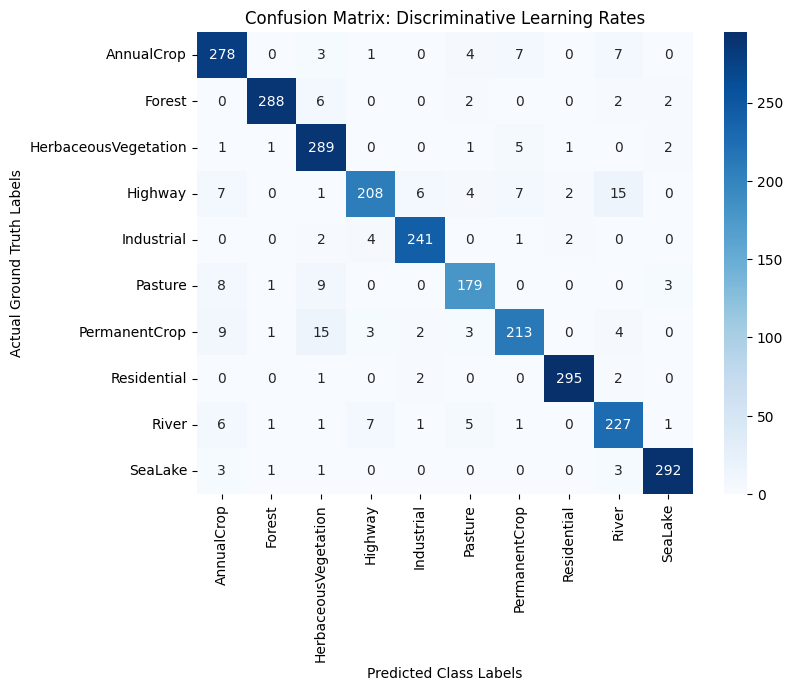

In [13]:
# Final Evaluation: Test Set + Confusion Matrix
# Loading Best Model Weights
if best_model_state_ft is not None:
    model_ft_2.load_state_dict(best_model_state_ft)

# Evaluating
evaluate_and_plot_matrix(
    model_ft_2,
    test_loader,
    "Discriminative Learning Rates"
    )

#### Experiment 3: Learning Rates Sceduling

In [15]:
# Importing ReduceLROnPlateau for Learning Rates Sceduling
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Setup: Create a copy of the baseline model
model_ft_3 = copy.deepcopy(baseline_model)
model_ft_3 = model_ft_3.to(device)

# UNFREEZING STRATEGY
# Freeze all parameters first
for param in model_ft_3.parameters():
    param.requires_grad = False

# Unfreeze the classifier
for param in model_ft_3.classifier[1].parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the backbone (features)
for i, child in enumerate(model_ft_3.features):
    if i >= 7: # Unfreezing layers 7, 8
        for param in child.parameters():
            param.requires_grad = True

# Training Configuration
optimizer_ft = optim.SGD(
    filter(lambda p: p.requires_grad, model_ft_3.parameters()), lr=0.1,
    momentum=0.0)

# Configure the Learning Rate Scheduler to monitor validation accuracy
scheduler = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.1, patience=5)
criterion_ft = nn.CrossEntropyLoss()
trial_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
early_stopping = EarlyStopping(patience=5, mode='max')

# Training Loop
num_epochs = 100
best_val_acc = 0.0
best_model_state_ft = None

print("\n" + "=" * 60)
print("IMPROVEMENT: Fine-Tuning with Learning Rates Sceduling")
print("=" * 60)

for epoch in range(100):
    # Training
      train_loss, train_acc = train_one_epoch(
          model_ft_3, train_loader, criterion_ft, optimizer_ft
      )

      # Validation
      val_loss, val_acc = validate(model_ft_3, val_loader, criterion_ft)

      # Update learning rate based on validation performance (Plateau detection)⁠
      scheduler.step(val_acc)

      # Save history for plotting
      trial_history['train_acc'].append(train_acc)
      trial_history['val_acc'].append(val_acc)
      trial_history['train_loss'].append(train_loss)
      trial_history['val_loss'].append(val_loss)

      print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
            f"LR: {optimizer_ft.param_groups[0]['lr']:.6f} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

      if val_acc > best_val_acc:
          best_val_acc = val_acc
          best_model_state_ft = copy.deepcopy(model_ft_3.state_dict())
          print(" ✓ Best!", end="")

      print()

      # Early Stopping
      early_stopping(val_acc)
      if early_stopping.early_stop:
          print(f"\nEarly stopping at epoch {epoch+1}")
          break

# Store results for comparison
new_result = pd.DataFrame([{'model_state': best_model_state_ft, 'history': trial_history, 'experiment_name': 'Learning Rates Sceduling'}])
ft_experiment_results = pd.concat([ft_experiment_results, new_result], ignore_index=True)
print(f"\nOptimization Finished. Best Validation Accuracy: {best_val_acc:.2f}%")


IMPROVEMENT: Fine-Tuning with Learning Rates Sceduling
Epoch [ 1/100] | LR: 0.100000 | Train Loss: 0.3699 | Train Acc: 87.50% | Val Loss: 0.3746 | Val Acc: 88.89% ✓ Best!
Epoch [ 2/100] | LR: 0.100000 | Train Loss: 0.1923 | Train Acc: 93.56% | Val Loss: 0.2993 | Val Acc: 91.30% ✓ Best!
Epoch [ 3/100] | LR: 0.100000 | Train Loss: 0.1544 | Train Acc: 94.81% | Val Loss: 0.2441 | Val Acc: 92.96% ✓ Best!
Epoch [ 4/100] | LR: 0.100000 | Train Loss: 0.0756 | Train Acc: 97.55% | Val Loss: 0.2504 | Val Acc: 92.59%
   [EarlyStopping Update] No improvement counter: 1 out of 5
Epoch [ 5/100] | LR: 0.100000 | Train Loss: 0.0671 | Train Acc: 97.73% | Val Loss: 0.2228 | Val Acc: 92.59%
   [EarlyStopping Update] No improvement counter: 2 out of 5
Epoch [ 6/100] | LR: 0.100000 | Train Loss: 0.0562 | Train Acc: 98.06% | Val Loss: 0.2557 | Val Acc: 91.67%
   [EarlyStopping Update] No improvement counter: 3 out of 5
Epoch [ 7/100] | LR: 0.100000 | Train Loss: 0.0491 | Train Acc: 98.33% | Val Loss: 0.2581


METRICS REPORT: Learning Rates Sceduling
Top-1 Accuracy: 94.63% | Top-5 Accuracy: 99.96%
Precision: 0.9457 | Recall: 0.9438



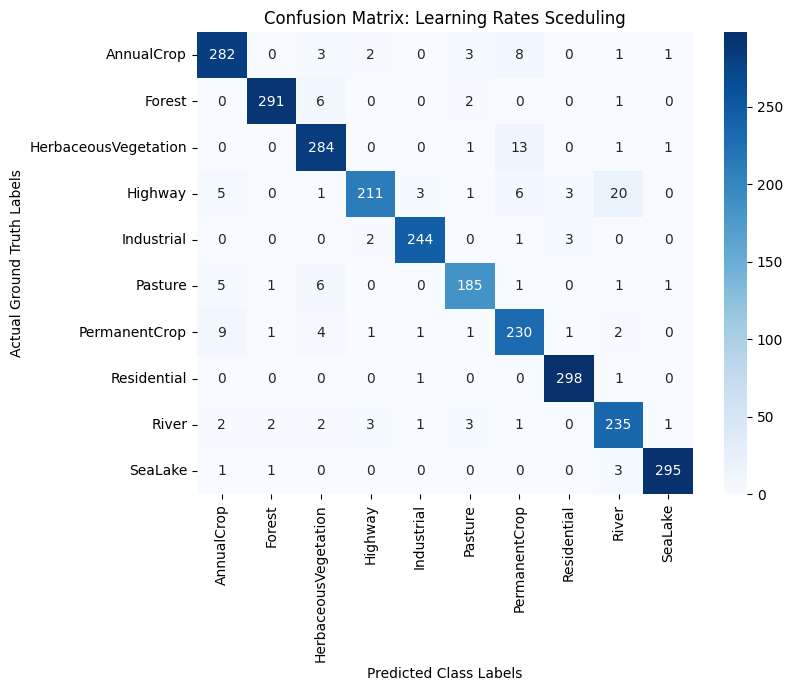

In [16]:
# Final Evaluation: Test Set + Confusion Matrix
# Loading Best Model Weights
if best_model_state_ft is not None:
    model_ft_3.load_state_dict(best_model_state_ft)

# Evaluating
evaluate_and_plot_matrix(
    model_ft_3,
    test_loader,
    "Learning Rates Sceduling"
    )

#### Combined Performance Comparison

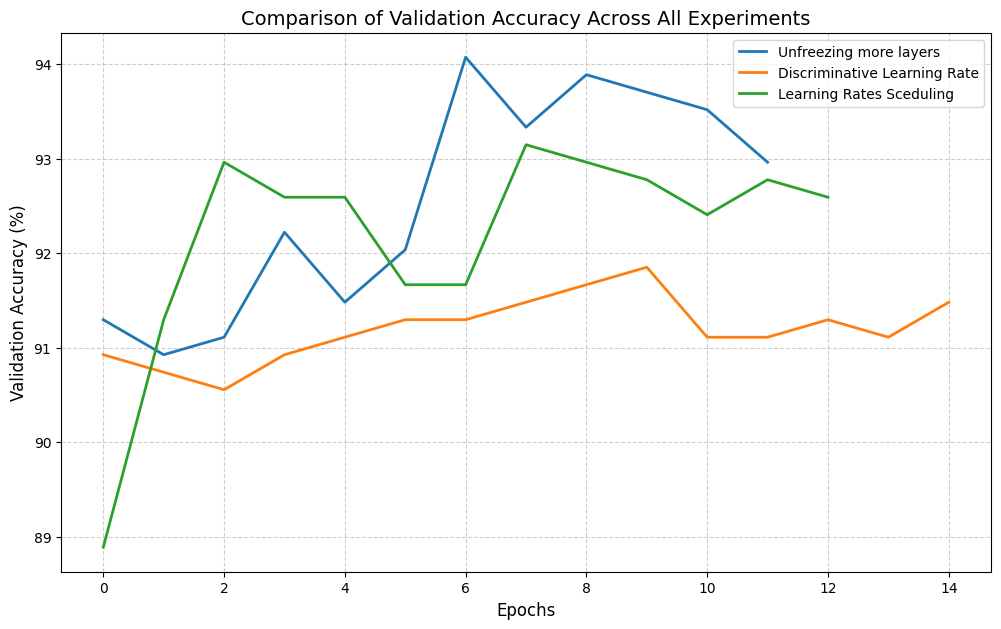

In [17]:
# Set the figure size to ensure the plot is clear and readable
plt.figure(figsize=(12, 7))

# Iterate through each row in the experiments dataframe
for i, row in ft_experiment_results.iterrows():
    # Plot the validation accuracy trajectory for the current experiment
    # Using the experiment name as the legend label
    plt.plot(row['history']['val_acc'], label=row['experiment_name'], linewidth=2)

# Set plot title and axis labels
plt.title('Comparison of Validation Accuracy Across All Experiments', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)

# Add a legend to distinguish between different experiments
plt.legend(fontsize=10)

# Enable grid for better visualization of specific values
plt.grid(True, linestyle='--', alpha=0.6)

# Render the final plot
plt.show()